## Assignment: Image recognition
- Alumno 1: Yousef Medhat
- Alumno 2: Carlos Manzano Izquierdo
- Alumno 3: Guillermo Bermejo Babiano

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# The -q flag means "quiet" so it doesn't print 10,000 lines and crash your browser
!unzip -q "/content/drive/MyDrive/DL/xview_recognition.zip" -d "/content/dataset"

print("✅ Unzipping complete!")

✅ Unzipping complete!


In [3]:
data_dir = '/content/dataset/xview_recognition' # Or whatever the extracted folder is named

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [6]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [7]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('../content/dataset/xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [8]:
import json

# Load database
json_file = '../content/dataset/xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [9]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [10]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 16871
Number of validation images: 1875


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L2

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    BatchNormalization(),

    # Block 1: 512 Neurons
    Dense(512, kernel_initializer='he_normal'), # Eliminado L2
    BatchNormalization(),
    Activation('swish'),
    Dropout(0.1), # Reducido de 0.3 a 0.1 para que retenga más información

    # Block 2: 256 Neurons
    Dense(256, kernel_initializer='he_normal'), # Eliminado L2
    BatchNormalization(),
    Activation('swish'),
    Dropout(0.1), # Reducido de 0.3 a 0.1

    # Block 3: 128 Neurons
    Dense(128, kernel_initializer='he_normal'), # Eliminado L2
    BatchNormalization(),
    Activation('swish'),
    Dropout(0.1), # Reducido de 0.2 a 0.1

    # Output Layer
    Dense(len(categories), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12288)          │        49,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,510,605 (24.84 MB)

 Trainable params: 6,484,237 (24.74 MB)

 Non-trainable params: 26,368 (103.00 KB)

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalFocalCrossentropy

focal_loss = CategoricalFocalCrossentropy(
    gamma=2.0,
    from_logits=False,
    label_smoothing=0.1
)

opt = Adam(learning_rate=0.001)

model.compile(optimizer=opt, loss=focal_loss, metrics=['accuracy'])

In [14]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_delta=0.001,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [15]:
def generator_from_ram(X_data, y_data, batch_size, do_shuffle=False, do_augment=False):
    # Índices para saber qué foto toca
    indices = np.arange(len(X_data))

    while True:
        if do_shuffle:
            np.random.shuffle(indices)

        # Troceamos los índices en batches
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]

            # Cogemos las imágenes crudas de la RAM
            batch_images_raw = X_data[batch_indices]
            batch_cats = y_data[batch_indices]

            images, labels = [], []

            for j in range(len(batch_images_raw)):
                # Copiamos la imagen para no modificar la original en RAM
                img = batch_images_raw[j].copy()
                cat = batch_cats[j]

                # ==========================================
                # AUGMENTATION "SAFE MODE" (Solo Brillo y Giros)
                # ==========================================
                if do_augment:
                    # 1. ROTACIÓN (90, 180, 270)
                    k = np.random.randint(0, 4)
                    if k > 0: img = np.rot90(img, k)

                    # 2. FLIP (Espejo)
                    if np.random.rand() > 0.5:
                        code = np.random.choice([0, 1])
                        img = cv2.flip(img, code)

                    # 3. BRILLO/CONTRASTE (Sin Traslación)
                    # Lo aplicamos el 80% de las veces para dar variedad de color
                    if np.random.rand() > 0.2:
                        alpha = np.random.uniform(0.8, 1.2) # Contraste
                        beta = np.random.uniform(-25, 25)   # Brillo
                        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
                # ==========================================

                # Normalización (Aquí pasamos a float)
                img_float = img.astype(np.float32) / 255.0

                # One-Hot Encoding
                prob = np.zeros(len(categories))
                prob[list(categories.values()).index(cat)] = 1

                images.append(img_float)
                labels.append(prob)

            yield np.array(images), np.array(labels)

In [16]:
import numpy as np
import cv2
from tqdm import tqdm  # Barra de progreso

def load_dataset_to_ram(objs_list, target_size=(64, 64)):
    print(f"Cargando {len(objs_list)} imágenes en RAM... ")

    X_data = []
    y_labels = []

    for filename, obj in tqdm(objs_list):
        # 1. Cargar
        img = load_geoimage(filename)

        # 2. Redimensionar a target size
        # (Es vital para poder apilarlas en un array de Numpy)
        if img.shape[:2] != target_size:
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        # 3. Guardar tal cual (uint8, 0-255).
        # NO dividas por 255 aquí o ocuparás 4 veces más RAM.
        X_data.append(img)
        y_labels.append(obj.category)

    # Convertir a Bloque Numpy
    X_data = np.array(X_data, dtype='uint8')
    y_labels = np.array(y_labels)

    print(f"¡Carga lista! Ocupa en RAM: {X_data.nbytes / 1024 / 1024:.2f} MB")
    return X_data, y_labels

In [17]:
def balance_dataset_list(objs):
    # 1. Contamos cuántos hay de cada clase originalmente
    counts = {}
    for _, obj in objs:
        c = obj.category
        counts[c] = counts.get(c, 0) + 1

    print("--- CONTEO ORIGINAL ---")
    print(counts)

    balanced_objs = []

    # CONFIGURACIÓN DE OBJETIVOS
    TARGET_STANDARD = 2000  # Objetivo para la mayoría (Pylons, Barcos, Camiones...)
    TARGET_TINY = 1000      # Objetivo conservador para las muy pequeñas (Helipuertos)
    TINY_THRESHOLD = 200    # Si tiene menos de 200, usamos el objetivo 'Tiny'

    for filename, obj in objs:
        # Siempre añadimos la imagen original
        balanced_objs.append((filename, obj))

        current_count = counts[obj.category]

        # Determinamos el objetivo según el tamaño de la clase
        if current_count < TINY_THRESHOLD:
            target = TARGET_TINY  # Caso Helipuertos (111 -> ~1000)
        else:
            target = TARGET_STANDARD # Caso Pylons/Trucks (300 -> ~2000)

        # Si estamos por debajo del objetivo, calculamos copias
        if current_count < target:
            # Ejemplo Pylon (312): 2000 / 312 = 6.4 -> Multiplicador 6 (Total 7 copias)
            # Ejemplo Helipuerto (111): 1000 / 111 = 9.0 -> Multiplicador 9 (Total 10 copias)
            # Restamos 1 porque ya añadimos la original arriba
            multiplier = int(target / current_count) - 1

            # Solo añadimos si el multiplicador es positivo
            if multiplier > 0:
                for _ in range(multiplier):
                    balanced_objs.append((filename, obj))

    print(f"\n--- DATASET BALANCEADO ---")
    print(f"De {len(objs)} imágenes pasamos a {len(balanced_objs)} imágenes virtuales.")

    return balanced_objs

In [18]:
# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

# PASO 1: Balanceo de clases
print("--- FASE 1: Balanceo ---")
objs_train_balanced = balance_dataset_list(objs_train)


# PASO 2: Cargar todo en RAM
# -------------------------------------------------------
print("\n--- FASE 2: Carga en RAM ---")
# Train con lista inflada
X_train_ram, y_train_ram = load_dataset_to_ram(objs_train_balanced)
# Valid con lista normal
X_valid_ram, y_valid_ram = load_dataset_to_ram(objs_valid)

# PASO 3: Crear Generadores Rápidos
# -------------------------------------------------------
batch_size = 32

train_gen = generator_from_ram(
    X_train_ram, y_train_ram,
    batch_size=batch_size,
    do_shuffle=True,
    do_augment=True
)

valid_gen = generator_from_ram(
    X_valid_ram, y_valid_ram,
    batch_size=batch_size,
    do_shuffle=False,
    do_augment=False
)

--- FASE 1: Balanceo ---
--- CONTEO ORIGINAL ---
{'Bus': 1594, 'Cargo plane': 576, 'Truck': 1969, 'Building': 3231, 'Fishing vessel': 633, 'Small car': 2995, 'Pylon': 280, 'Shipping container': 1388, 'Dump truck': 1118, 'Motorboat': 960, 'Storage tank': 1317, 'Excavator': 708, 'Helipad': 102}

--- DATASET BALANCEADO ---
De 16871 imágenes pasamos a 23453 imágenes virtuales.

--- FASE 2: Carga en RAM ---
Cargando 23453 imágenes en RAM... 


100%|██████████| 23453/23453 [01:10<00:00, 333.44it/s]


¡Carga lista! Ocupa en RAM: 274.84 MB
Cargando 1875 imágenes en RAM... 


100%|██████████| 1875/1875 [00:05<00:00, 368.80it/s]

¡Carga lista! Ocupa en RAM: 21.97 MB


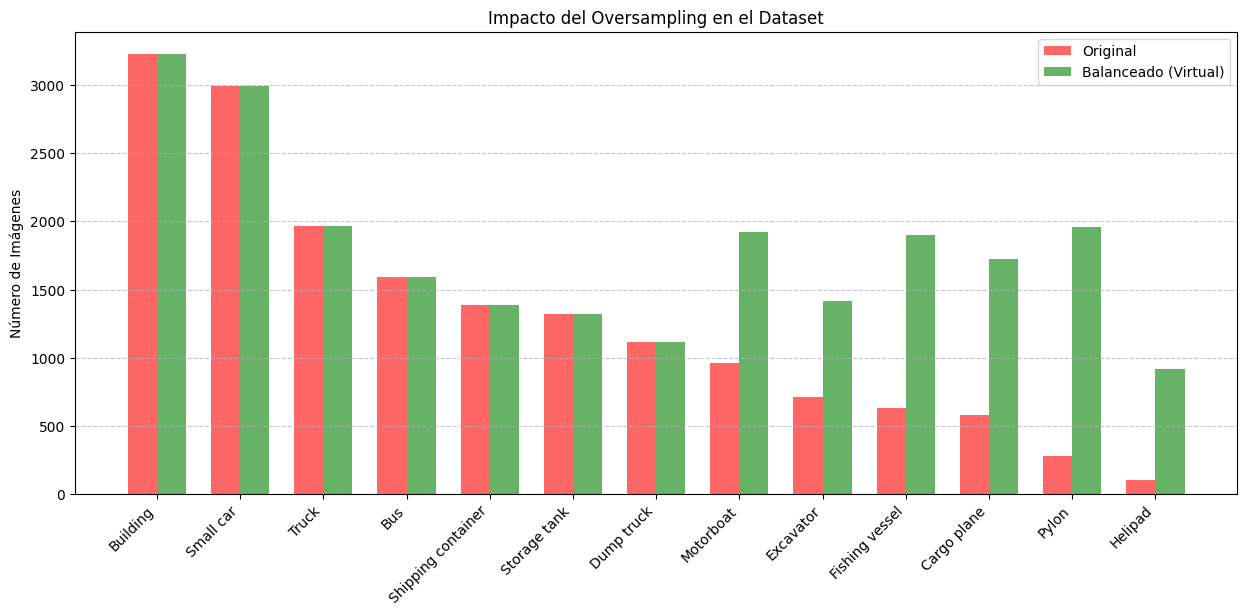

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_balance(original_objs, balanced_objs):
    # 1. Contar Originales
    counts_orig = {}
    for _, obj in original_objs:
        counts_orig[obj.category] = counts_orig.get(obj.category, 0) + 1

    # 2. Contar Balanceados
    counts_bal = {}
    for _, obj in balanced_objs:
        counts_bal[obj.category] = counts_bal.get(obj.category, 0) + 1

    # Preparar datos para plot
    classes = list(counts_orig.keys())
    # Ordenamos por cantidad original para que quede bonito
    classes.sort(key=lambda x: counts_orig[x], reverse=True)

    vals_orig = [counts_orig[c] for c in classes]
    vals_bal = [counts_bal[c] for c in classes]

    x = range(len(classes))
    width = 0.35

    plt.figure(figsize=(15, 6))
    plt.bar([i - width/2 for i in x], vals_orig, width, label='Original', color='red', alpha=0.6)
    plt.bar([i + width/2 for i in x], vals_bal, width, label='Balanceado (Virtual)', color='green', alpha=0.6)

    plt.xticks(x, classes, rotation=45, ha='right')
    plt.ylabel('Número de Imágenes')
    plt.title('Impacto del Oversampling en el Dataset')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# USARLO:
plot_class_balance(objs_train, objs_train_balanced)

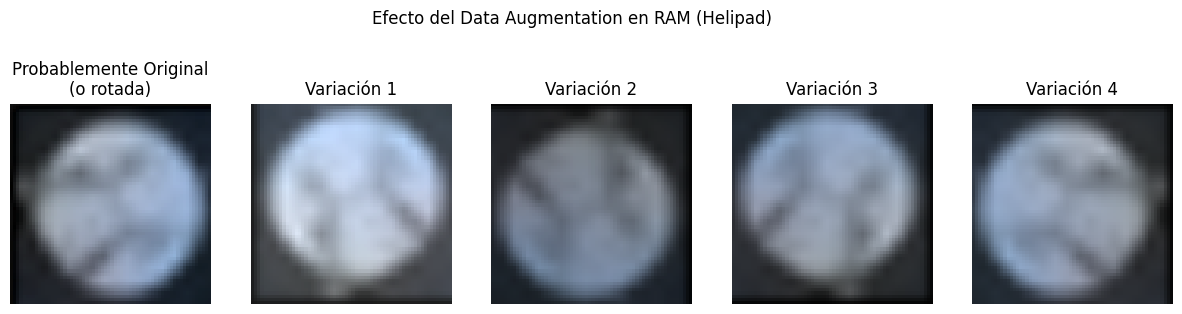

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_ram_augmentation(X_data, y_data, generator_func):
    # 1. Buscar índices de Helipuertos (o la clase que quieras ver)
    # Asumimos que y_data tiene los nombres de las clases (strings)
    indices = np.where(y_data == 'Helipad')[0]

    if len(indices) == 0:
        print("No se encontraron Helipuertos en los datos proporcionados.")
        return

    idx = indices[0] # Cogemos el primer helipuerto que encontremos

    # 2. Extraer la imagen y la etiqueta originales de la RAM
    sample_img = X_data[idx]
    sample_cat = y_data[idx]

    # 3. Crear un "Mini Batch Falso" de 5 copias idénticas
    # Repetimos la imagen 5 veces: (5, 64, 64, 3)
    fake_X = np.array([sample_img] * 5)
    fake_y = np.array([sample_cat] * 5)

    # 4. Instanciar el generador con estos datos falsos
    # Le decimos batch_size=5 para que nos devuelva las 5 de golpe
    gen = generator_func(fake_X, fake_y, batch_size=5, do_shuffle=False, do_augment=True)

    images_aug, _ = next(gen) # Sacamos el batch procesado

    # 5. Pintar
    plt.figure(figsize=(15, 4))
    for i in range(5):
        plt.subplot(1, 5, i+1)

        # Las imágenes vienen normalizadas (0-1) y en float32
        img_show = images_aug[i]

        # Si usaste cv2 para cargar, están en BGR. Matplotlib quiere RGB.
        # Hacemos el flip de canales con ::-1
        plt.imshow(img_show[:, :, ::-1])

        if i == 0:
            plt.title("Probablemente Original\n(o rotada)")
        else:
            plt.title(f"Variación {i}")
        plt.axis('off')

    plt.suptitle(f"Efecto del Data Augmentation en RAM ({sample_cat})")
    plt.show()

# --- CÓMO USARLO AHORA ---
# Importante: Pasa las variables _ram, NO la lista de objetos
visualize_ram_augmentation(X_train_ram, y_train_ram, generator_from_ram)

In [21]:
import math
import numpy as np

print('Training model')
epochs = 100
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
h = model.fit(train_gen, steps_per_epoch=train_steps, validation_data=valid_gen, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks, verbose=1)
# Best validation model
best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Training model
Epoch 1/100
523/528 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2686 - loss: 0.4648
Epoch 1: val_accuracy improved from -inf to 0.35467, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.2691 - loss: 0.4644 - val_accuracy: 0.3547 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 2/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3787 - loss: 0.3874
Epoch 2: val_accuracy improved from 0.35467 to 0.38773, saving model to model.keras
528/528 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.3788 - loss: 0.3873 - val_accuracy: 0.3877 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 3/100
528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4213 - loss: 0.3658
Epoch 3: val_accuracy did not improve from 0.38773
528/528 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4213 - loss: 0.3658 - val_accuracy: 0.3787 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 4/100
527/528 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4433 - loss:

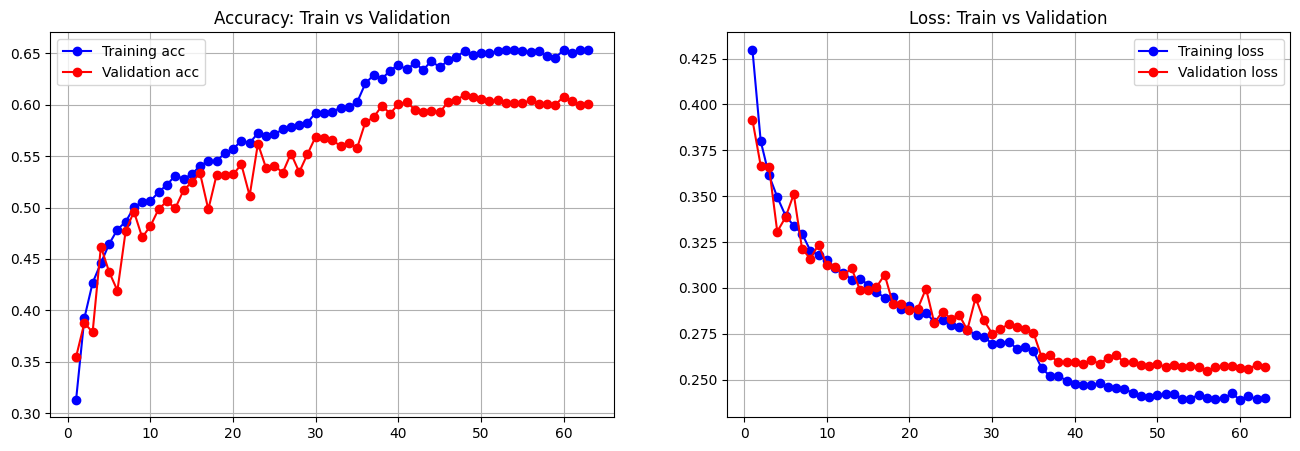

In [22]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 5))

    # Gráfica de Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation acc')
    plt.title('Accuracy: Train vs Validation')
    plt.legend()
    plt.grid(True)

    # Gráfica de Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title('Loss: Train vs Validation')
    plt.legend()
    plt.grid(True)

    plt.show()

# USARLO:
plot_history(h)

Generando predicciones... esto puede tardar unos segundos.
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


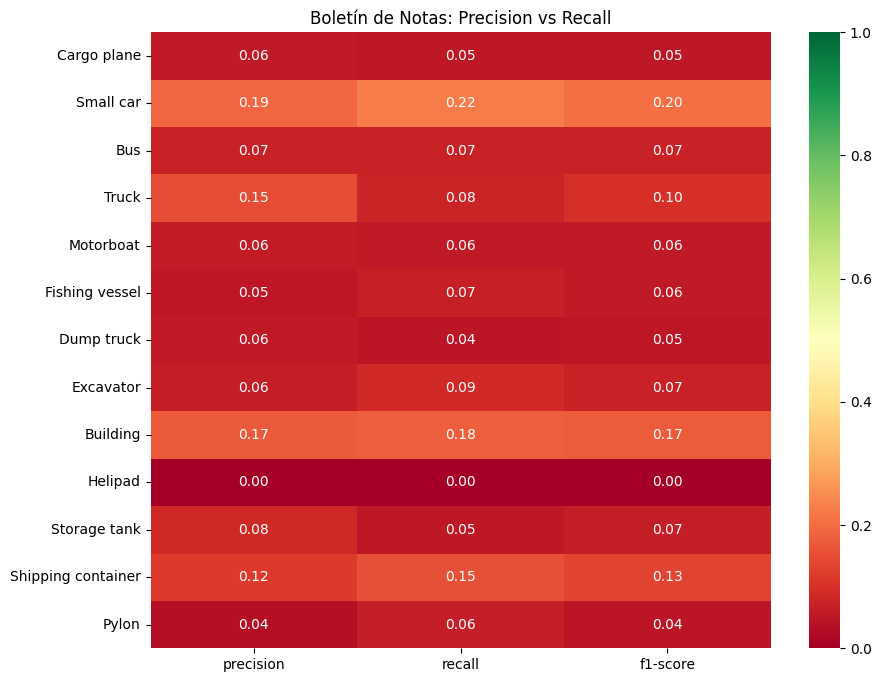

In [23]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_classification_report(model, valid_gen, steps):
    print("Generando predicciones... esto puede tardar unos segundos.")

    # 1. Predecir
    y_pred = model.predict(valid_gen, steps=steps, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1) # Convierte [0.1, 0.9, 0] -> 1

    # 2. Etiquetas reales (CORREGIDO)
    # Como y_valid_ram tiene textos ('Helipad'), hay que pasarlos a números (0, 1, 2...)
    # Usamos el orden de 'categories' para saber qué número es cada texto.
    class_names = list(categories.values()) # ['Cargo plane', 'Small car', ...]

    # Mapeamos cada texto de la RAM a su número
    y_true = np.array([class_names.index(cat) for cat in y_valid_ram])

    # AJUSTE VITAL:
    # Al usar steps = len // batch_size, es posible que 'y_pred' sea un poco más corto
    # que 'y_true' (porque se descarta el último batch incompleto).
    # Cortamos y_true para que tenga la misma longitud exacta que y_pred.
    y_true = y_true[:len(y_pred_classes)]

    # 3. Reporte
    report = classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0 # Evita errores si alguna clase no se predice nunca
    )

    # Convertimos a DataFrame y limpiamos
    df = pd.DataFrame(report).transpose()
    df = df.drop(['accuracy', 'macro avg', 'weighted avg'])

    # 4. Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.iloc[:, :3], annot=True, cmap='RdYlGn', fmt='.2f', vmin=0, vmax=1)
    plt.title('Boletín de Notas: Precision vs Recall')
    plt.show()

# USARLO:
# Asegúrate de pasar el BATCH_SIZE correcto (el mismo que usaste en valid_gen)
plot_classification_report(model, valid_gen, len(X_valid_ram)//batch_size)

Analizando errores... (Prediciendo todo el set)
Total de errores: 732 de 1875 (39.04%)


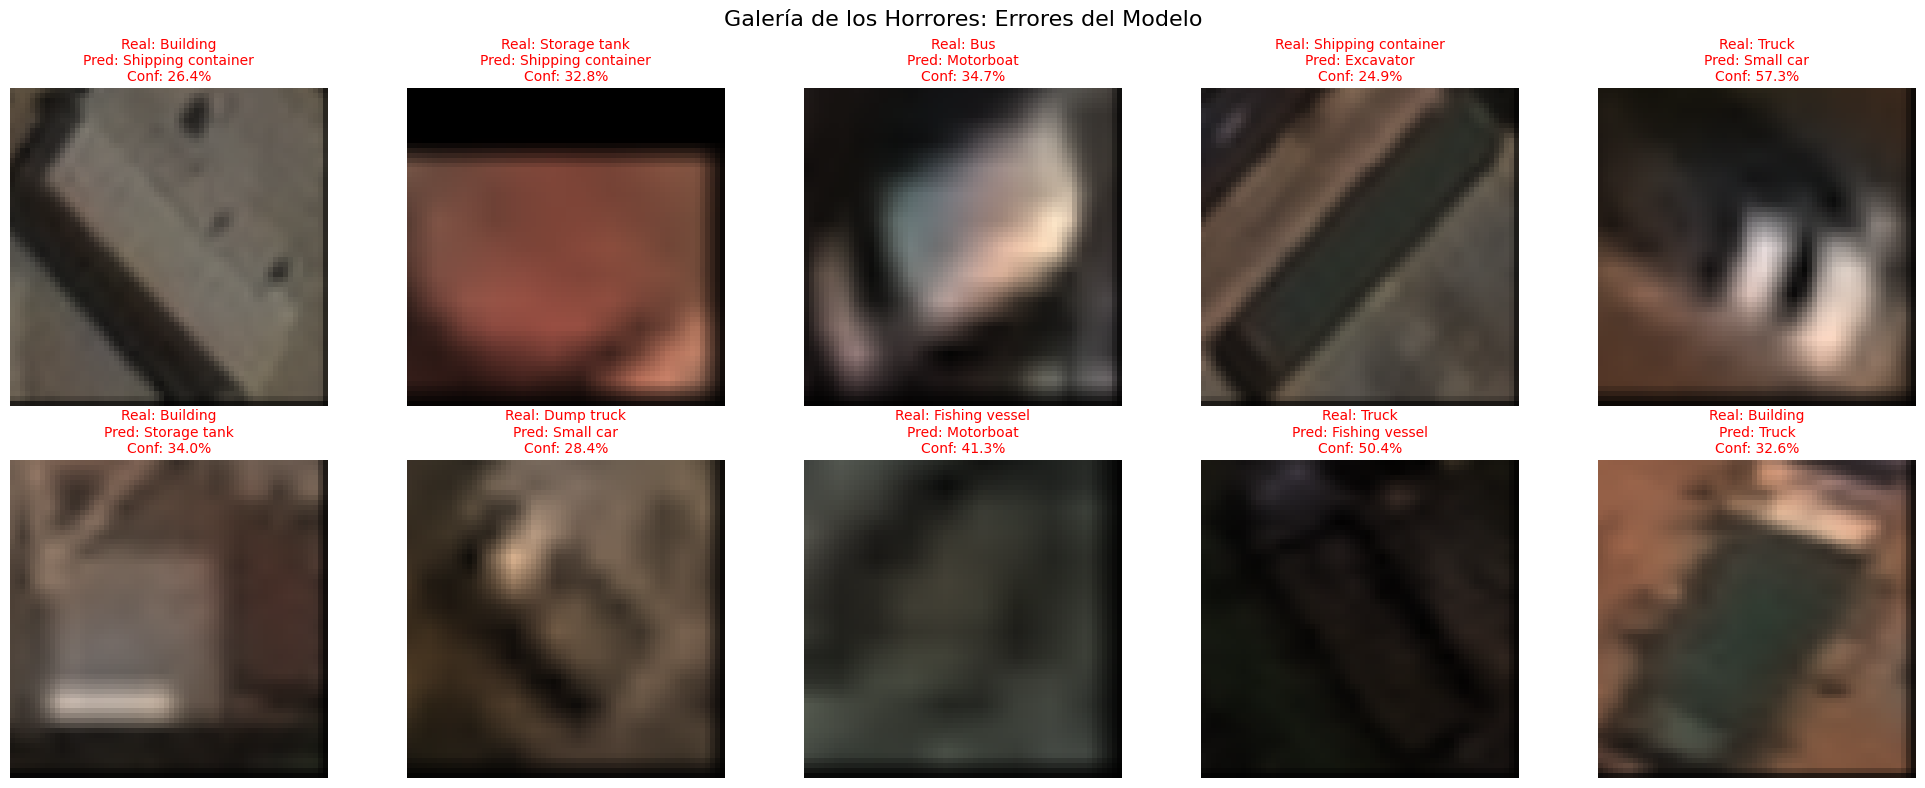

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_errors(model, X_data, y_data):
    print("Analizando errores... (Prediciendo todo el set)")

    # 1. Predecir todo
    # Normalizamos al vuelo (/255.0) porque en RAM están como uint8
    preds = model.predict(X_data.astype('float32') / 255.0, verbose=0)

    # Obtenemos la clase predicha (Número)
    pred_classes = np.argmax(preds, axis=1)

    # 2. Obtener la clase real (CORRECCIÓN AQUÍ)
    # Como y_data son textos ('Helipad'), los convertimos a números
    class_names = list(categories.values()) # ['Cargo plane', 'Small car', ...]

    # Mapeamos: 'Helipad' -> 9 (o el número que sea)
    true_classes = np.array([class_names.index(cat) for cat in y_data])

    # 3. Buscar discrepancias
    errors = np.where(pred_classes != true_classes)[0]
    print(f"Total de errores: {len(errors)} de {len(X_data)} ({(len(errors)/len(X_data))*100:.2f}%)")

    # Si no hay errores, salimos
    if len(errors) == 0:
        print("¡Increíble! 0 errores encontrados.")
        return

    # 4. Mostrar 10 errores aleatorios
    # Si hay menos de 10 errores, los mostramos todos
    n_show = min(10, len(errors))
    indices_to_show = np.random.choice(errors, size=n_show, replace=False)

    plt.figure(figsize=(20, 8))
    for i, idx in enumerate(indices_to_show):
        plt.subplot(2, 5, i+1)

        # Imagen (Original de RAM)
        img = X_data[idx]

        # Si usas OpenCV, recuerda que carga en BGR, matplotlib quiere RGB
        # Si ves los colores raros (azul en vez de rojo), descomenta la linea de abajo:
        # img = img[:, :, ::-1]
        plt.imshow(img)

        # Etiquetas
        true_label = class_names[true_classes[idx]]
        pred_label = class_names[pred_classes[idx]]

        # Confianza: ¿Cómo de seguro estaba el modelo de su error?
        conf = np.max(preds[idx]) * 100

        # T = Truth (Verdad), P = Prediction (Predicción)
        plt.title(f"Real: {true_label}\nPred: {pred_label}\nConf: {conf:.1f}%", color='red', fontsize=10)
        plt.axis('off')

    plt.suptitle("Galería de los Horrores: Errores del Modelo", fontsize=16)
    plt.tight_layout()
    plt.show()

# USARLO:
visualize_errors(model, X_valid_ram, y_valid_ram)

#### Validation
Compute validation metrics.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [26]:
# 1. Usamos los datos que YA cargamos en RAM (Velocidad: 100x más rápido)
# model.predict procesa todo el bloque de golpe (Batch processing)
print("Prediciendo todo el validación de golpe...")
predictions = model.predict(X_valid_ram.astype('float32') / 255.0, batch_size=32, verbose=1)

# 2. Sacamos la clase ganadora de cada foto
y_pred_indices = np.argmax(predictions, axis=1) # [0, 5, 2...]

# 3. Convertimos números a nombres (si lo necesitas en texto)
class_names = list(categories.values())
y_pred = [class_names[i] for i in y_pred_indices]

# 4. Sacamos el y_true (La realidad)
# Si y_valid_ram era texto:
y_true = y_valid_ram
# Si y_valid_ram era One-Hot o índices, adáptalo.
# Asumiendo que es la lista de textos que devolvía load_dataset_to_ram:
# (Si usaste mi última función, y_valid_ram es una lista de strings ['Helipad', 'Car'...])

Prediciendo todo el validación de golpe...
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


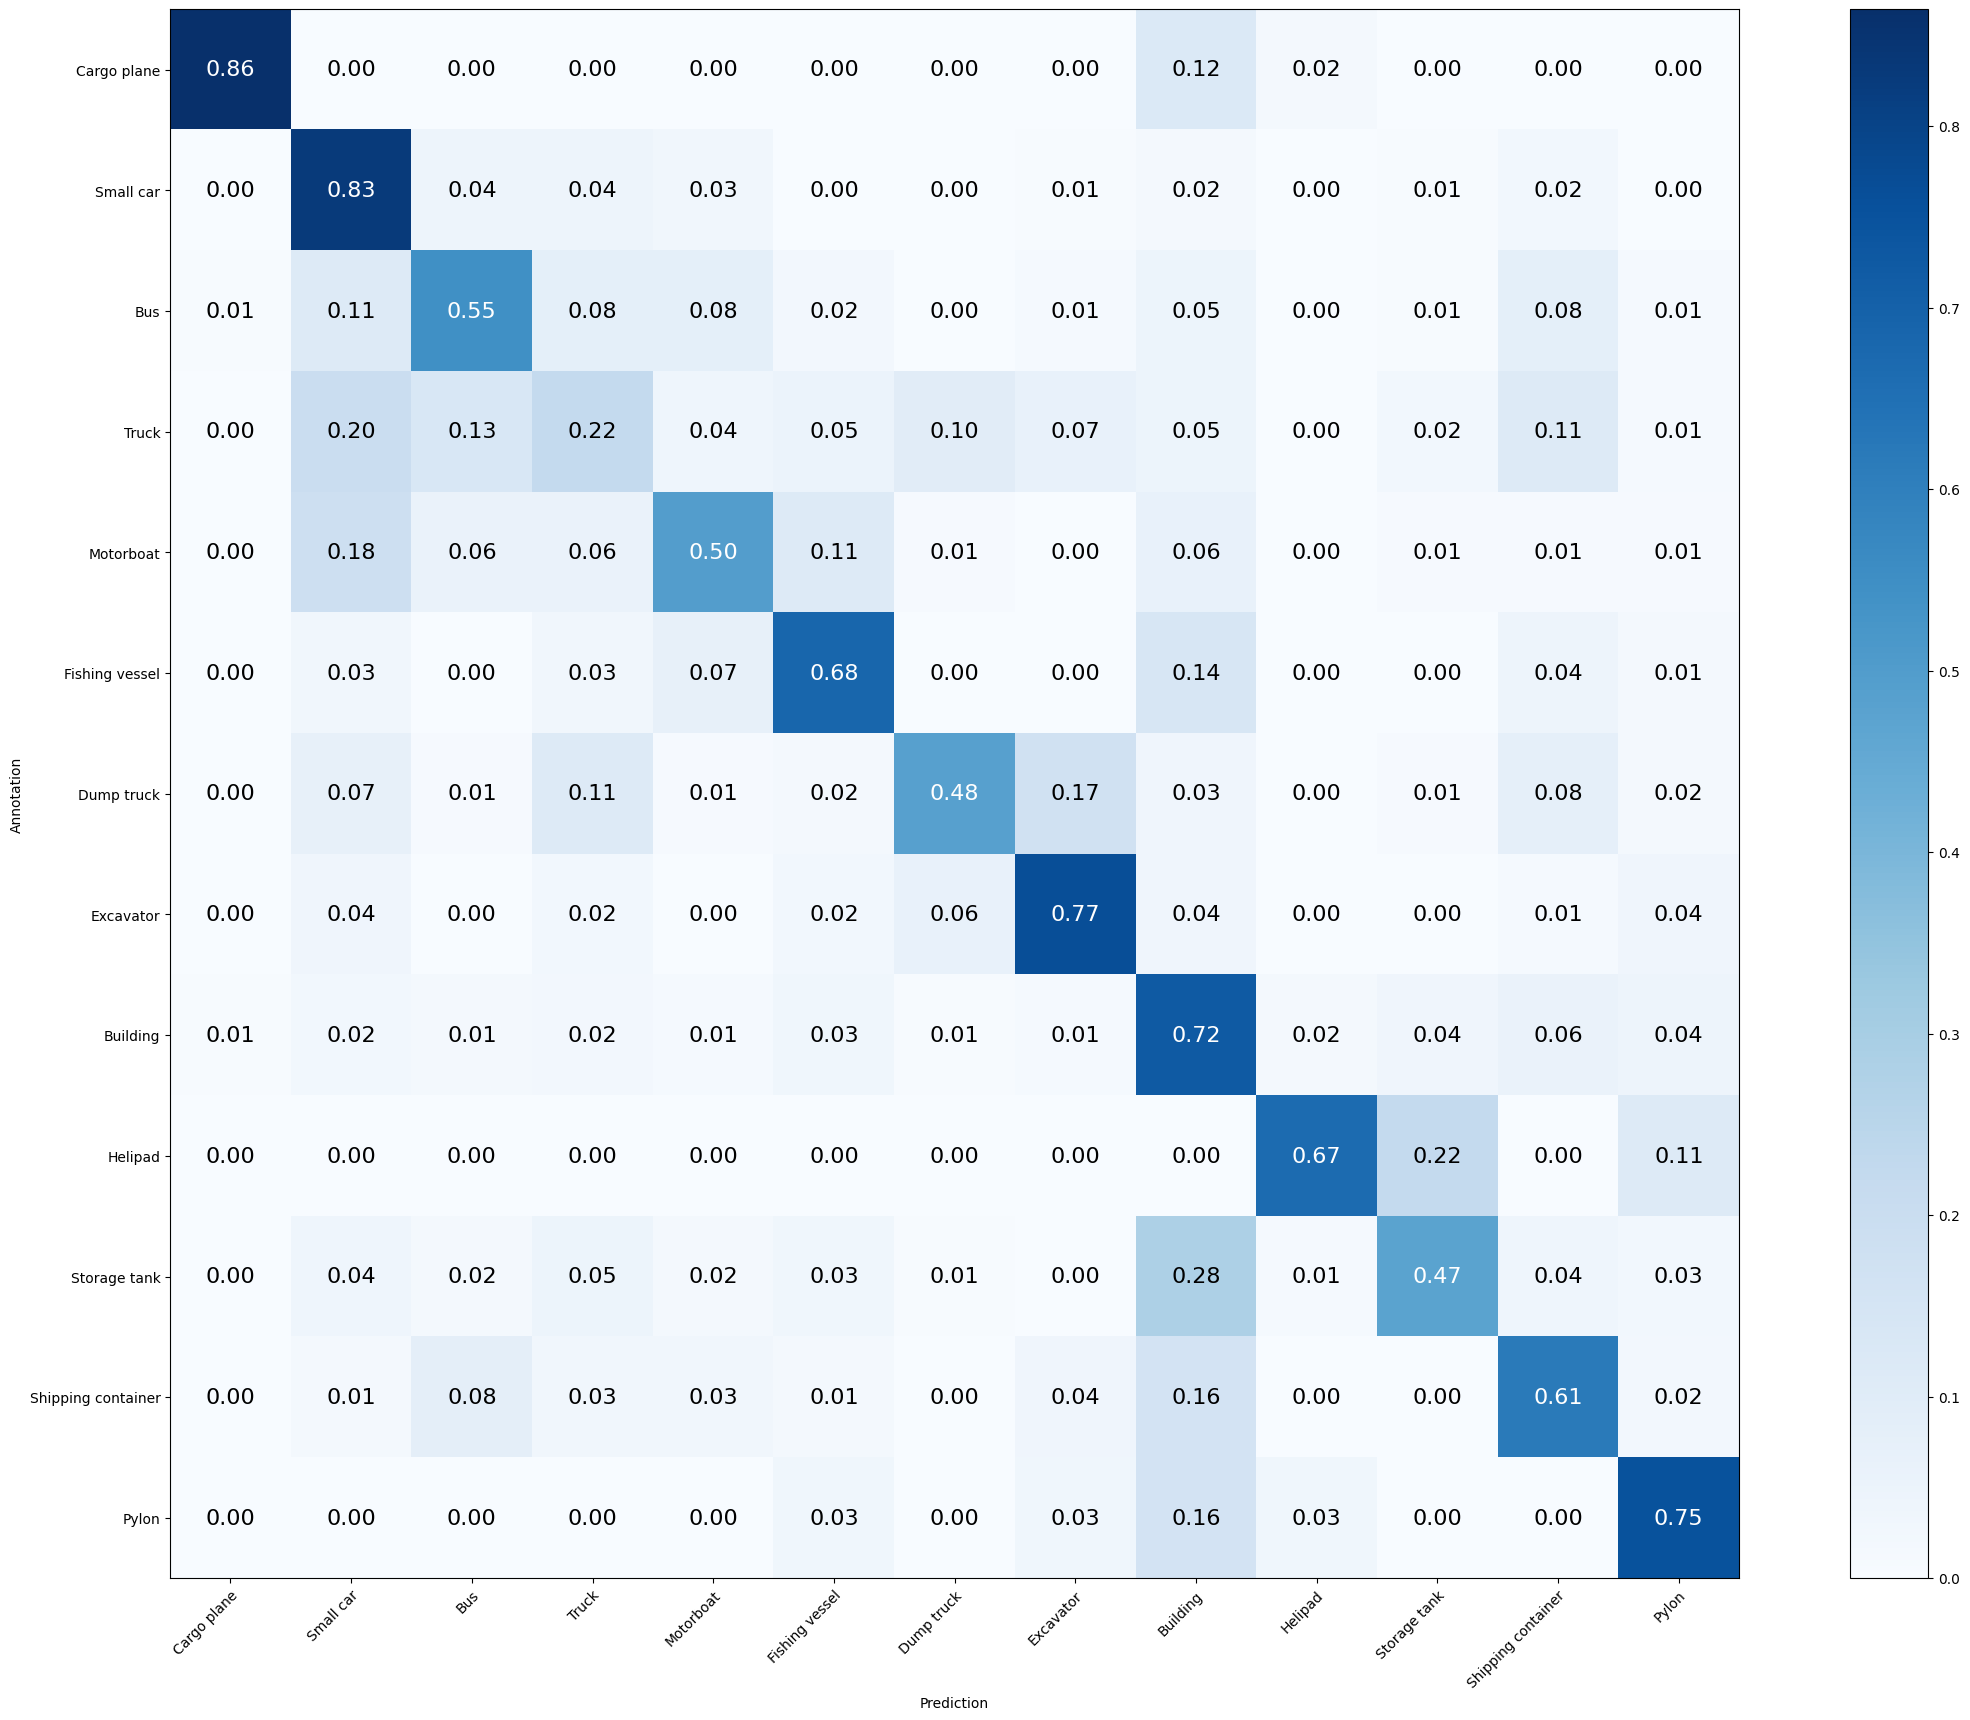

In [27]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [28]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 60.960%
Mean Recall: 62.451%
Mean Precision: 57.806%
> Cargo plane: Recall: 86.441% Precision: 94.444% Specificity: 99.835% Dice: 90.265%
> Small car: Recall: 82.979% Precision: 70.000% Specificity: 92.432% Dice: 75.939%
> Bus: Recall: 54.598% Precision: 56.886% Specificity: 95.767% Dice: 55.718%
> Truck: Recall: 21.992% Precision: 43.089% Specificity: 95.716% Dice: 29.121%
> Motorboat: Recall: 49.541% Precision: 52.427% Specificity: 97.225% Dice: 50.943%
> Fishing vessel: Recall: 68.493% Precision: 48.077% Specificity: 97.003% Dice: 56.497%
> Dump truck: Recall: 48.305% Precision: 63.333% Specificity: 98.122% Dice: 54.808%
> Excavator: Recall: 76.543% Precision: 55.357% Specificity: 97.213% Dice: 64.249%
> Building: Recall: 72.452% Precision: 67.959% Specificity: 91.799% Dice: 70.133%
> Helipad: Recall: 66.667% Precision: 37.500% Specificity: 99.464% Dice: 48.000%
> Storage tank: Recall: 47.368% Precision: 73.469% Specificity: 98.491% Dice: 57.600%
> Shipping container:

#### Testing
Try to improve the results provided in the competition.

In [29]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('../content/dataset/xview_recognition/xview_test'):
    for filename in filenames:
        image = GenericImage(dirpath[29:] + '/' + filename)
        image.tile = np.array([0, 0, 64, 64])
        obj = GenericObject()
        obj.bb = (0, 0, 64, 64)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [30]:
import numpy as np
import tensorflow as tf

model.load_weights('model.keras')
predictions_data = {"images": {}, "annotations": {}}

for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    # 1. Cargar imagen original
    # Fix: Remove 'gnition/' from the filename path which was incorrectly added
    try:
        image = load_geoimage(ann.filename[8:]) / 255.0
    except Exception as e:
        print(f"Error al cargar la ruta {ann.filename[8:]}. Saltando...")
        continue

    # --- FIX CRÍTICO: Comprobar que la imagen existe y redimensionar a 64x64 ---
    if image is None or image.size == 0:
        print(f"Advertencia: La imagen {ann.filename[8:]} se cargó vacía.")
        continue

    # Redimensionamos explícitamente al input_shape que espera nuestro modelo
    image_resized = tf.image.resize(image, (64, 64)).numpy()

    for obj_pred in ann.objects:
        # Generate prediction usando la imagen redimensionada
        warped_image = np.expand_dims(image_resized, 0)
        predictions = model.predict(warped_image, verbose=0)

        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = float(np.max(predictions)) # Casteado a float estándar de Python para evitar fallos en JSON

        annotation_data = {
            "image_id": ann.filename.split('/')[-1],
            "category_id": pred_category,
            "bbox": [int(x) for x in obj_pred.bb]
        }
        predictions_data["annotations"][idx] = annotation_data

print("Predicciones finalizadas correctamente.")

Predicciones finalizadas correctamente.


In [31]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)